In [1]:
# ============================================================
# EXAMEN PARCIAL - MACHINE LEARNING
# Alumno: Santiago Cama
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [2]:
# ============================================================
# CARGA DE DATASETS
# ============================================================

DATASET_DIR = Path("Dataset")

datasets = {}

for i in range(1, 11):
    archivo = DATASET_DIR / f"grupo_2_dataset_{i}.csv"

    try:
        df = pd.read_csv(archivo)
        datasets[i] = df

        print(
            f"Dataset {i}: "
            f"{df.shape[0]} filas x {df.shape[1]} columnas"
        )

    except Exception as e:
        print(f"Error cargando Dataset {i}: {e}")

Dataset 1: 27952 filas x 27 columnas
Dataset 2: 23666 filas x 30 columnas
Dataset 3: 9438 filas x 24 columnas
Dataset 4: 22540 filas x 16 columnas
Dataset 5: 31344 filas x 17 columnas
Dataset 6: 8372 filas x 24 columnas
Dataset 7: 5320 filas x 13 columnas
Dataset 8: 1616 filas x 25 columnas
Dataset 9: 35230 filas x 12 columnas
Dataset 10: 32386 filas x 13 columnas


## 1. Selección de datasets

Para el modelo individual de regresión se seleccionó el Dataset 5, cuya
variable objetivo `y1` es una variable continua.

Para el modelo individual de clasificación se seleccionó el Dataset 9,
cuya variable objetivo `y1` contiene 8 clases diferentes.

In [8]:
# ============================================================
# DATASETS SELECCIONADOS
# ============================================================

df_reg = datasets[5].copy()
df_clf = datasets[9].copy()

print("Dataset de REGRESIÓN")
print(df_reg.shape)

print("\nDataset de CLASIFICACIÓN")
print(df_clf.shape)

Dataset de REGRESIÓN
(31344, 17)

Dataset de CLASIFICACIÓN
(35230, 12)


## 2. Modelo individual de regresión

Se implementará un modelo Ridge Regression utilizando el Dataset 5.
Antes del entrenamiento se realiza un análisis exploratorio básico de los datos.

In [9]:
# ============================================================
# EDA - DATASET DE REGRESIÓN
# ============================================================

print("Dimensiones:")
print(df_reg.shape)

print("\nTipos de datos:")
print(df_reg.dtypes)

print("\nValores nulos:")
print(df_reg.isnull().sum())

print("\nDuplicados:")
print(df_reg.duplicated().sum())

print("\nEstadísticas descriptivas:")
display(df_reg.describe())

Dimensiones:
(31344, 17)

Tipos de datos:
x1     float64
x2     float64
x3     float64
x4     float64
x5     float64
x6     float64
x7     float64
x8     float64
x9     float64
x10    float64
x11    float64
x12    float64
x13    float64
x14    float64
x15    float64
x16    float64
y1     float64
dtype: object

Valores nulos:
x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
x11    0
x12    0
x13    0
x14    0
x15    0
x16    0
y1     0
dtype: int64

Duplicados:
0

Estadísticas descriptivas:


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,y1
count,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000,31344.000000
mean,8.354736,8.314320,8.116438,9.397174,7.754892,7.385298,8.288024,11.048410,6.668318,6.488141,7.299088,6.571561,10.625406,10.433238,6.828004,8.153567,-0.670175
std,5.879687,5.985903,5.572067,5.538547,6.005414,5.885806,5.462865,5.692528,5.763772,5.795388,4.991068,5.831000,5.631694,5.692688,5.620111,5.822875,192.709799
min,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-16.000000,-786.139690
25%,4.433876,4.348920,4.367248,5.687073,3.748375,3.400895,4.574702,7.221334,2.795208,2.591880,3.936192,2.623636,6.838463,6.616897,3.062020,4.229687,-129.385719
50%,8.330414,8.317735,8.127161,9.389490,7.778295,7.374937,8.331014,11.092049,6.696614,6.498084,7.257888,6.548066,10.622620,10.449487,6.771272,8.218429,-0.553844
75%,12.284372,12.335344,11.870311,13.081304,11.797946,11.400688,11.913645,14.880677,10.500981,10.417729,10.668768,10.528237,14.399844,14.294083,10.623668,12.043776,129.185038
max,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,879.795812


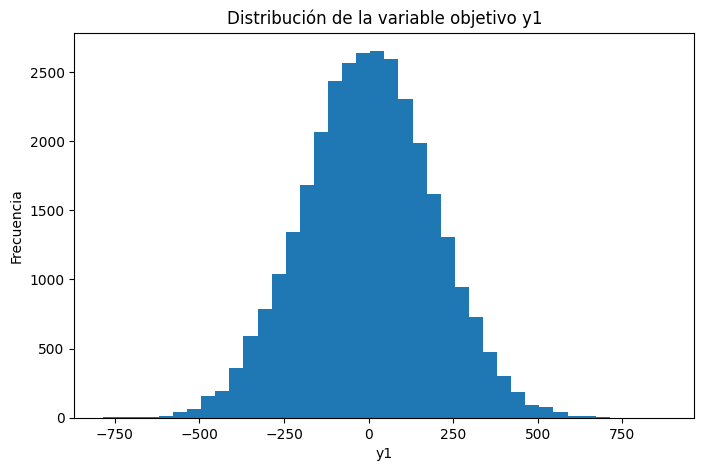

count    31344.000000
mean        -0.670175
std        192.709799
min       -786.139690
25%       -129.385719
50%         -0.553844
75%        129.185038
max        879.795812
Name: y1, dtype: float64


In [10]:
# ============================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(df_reg["y1"], bins=40)

plt.xlabel("y1")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo y1")

plt.show()

print(df_reg["y1"].describe())

In [11]:
# ============================================================
# CORRELACIÓN DE VARIABLES CON y1
# ============================================================

correlaciones = (
    df_reg.corr(numeric_only=True)["y1"]
    .drop("y1")
    .sort_values(key=abs, ascending=False)
)

display(correlaciones)

x14    0.509320
x6     0.486194
x7     0.458293
x2     0.396833
x13    0.253665
x12    0.246041
x9     0.098090
x1     0.012682
x15    0.011958
x5     0.011806
x8     0.011714
x10   -0.007258
x3     0.005336
x16   -0.003027
x11    0.002925
x4     0.000207
Name: y1, dtype: float64

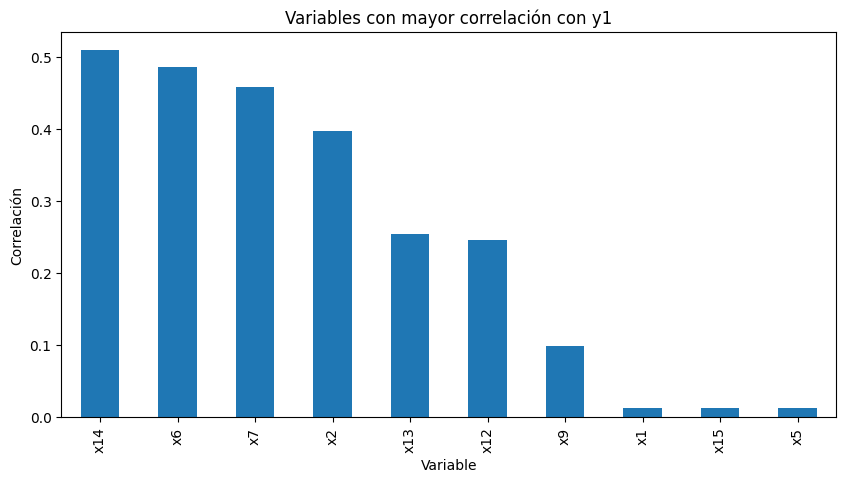

In [12]:
plt.figure(figsize=(10, 5))

correlaciones.head(10).plot(kind="bar")

plt.title("Variables con mayor correlación con y1")
plt.ylabel("Correlación")
plt.xlabel("Variable")

plt.show()

In [13]:
# ============================================================
# VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# ============================================================

X_reg = df_reg.drop(columns=["y1"])
y_reg = df_reg["y1"]

print("X:", X_reg.shape)
print("y:", y_reg.shape)

X: (31344, 16)
y: (31344,)


In [14]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Entrenamiento:", X_reg_train.shape)
print("Prueba:", X_reg_test.shape)

Entrenamiento: (25075, 16)
Prueba: (6269, 16)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()

X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

In [16]:
from sklearn.linear_model import Ridge

# ============================================================
# MODELO RIDGE REGRESSION
# ============================================================

modelo_reg = Ridge(
    alpha=1.0
)

modelo_reg.fit(
    X_reg_train_scaled,
    y_reg_train
)

y_reg_pred = modelo_reg.predict(
    X_reg_test_scaled
)

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [18]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominador = np.abs(y_true) + np.abs(y_pred)

    resultado = np.where(
        denominador == 0,
        0,
        2 * np.abs(y_pred - y_true) / denominador
    )

    return np.mean(resultado) * 100

In [19]:
mae_reg = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse_reg = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2_reg = r2_score(
    y_reg_test,
    y_reg_pred
)

smape_reg = smape(
    y_reg_test,
    y_reg_pred
)

print("RESULTADOS - RIDGE REGRESSION")
print("--------------------------------")
print(f"MAE   : {mae_reg:.4f}")
print(f"RMSE  : {rmse_reg:.4f}")
print(f"R2    : {r2_reg:.4f}")
print(f"SMAPE : {smape_reg:.4f}%")

RESULTADOS - RIDGE REGRESSION
--------------------------------
MAE   : 0.4983
RMSE  : 0.6224
R2    : 1.0000
SMAPE : 1.5604%


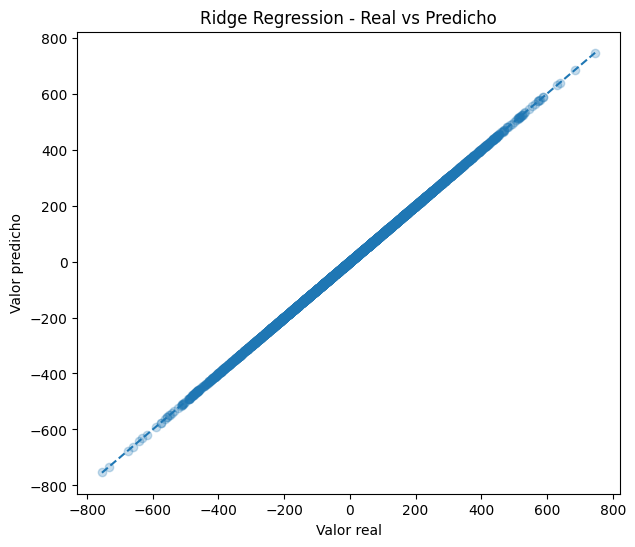

In [20]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_reg_test,
    y_reg_pred,
    alpha=0.25
)

min_val = min(
    y_reg_test.min(),
    y_reg_pred.min()
)

max_val = max(
    y_reg_test.max(),
    y_reg_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--"
)

plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Ridge Regression - Real vs Predicho")

plt.show()

## 3. Modelo individual de clasificación

Se implementará un modelo Decision Tree Classifier utilizando el Dataset 9.

La variable objetivo `y1` contiene ocho clases diferentes, por lo que
se trata de un problema de clasificación multiclase.

In [21]:
# ============================================================
# EDA - DATASET DE CLASIFICACIÓN
# ============================================================

print("Dimensiones:")
print(df_clf.shape)

print("\nTipos de datos:")
print(df_clf.dtypes)

print("\nValores nulos:")
print(df_clf.isnull().sum())

print("\nDuplicados:")
print(df_clf.duplicated().sum())

print("\nDistribución de clases:")
display(
    df_clf["y1"]
    .value_counts()
    .sort_index()
)

Dimensiones:
(35230, 12)

Tipos de datos:
x1     float64
x2     float64
x3     float64
x4     float64
x5     float64
x6     float64
x7     float64
x8     float64
x9     float64
x10    float64
x11    float64
y1       int64
dtype: object

Valores nulos:
x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
x11    0
y1     0
dtype: int64

Duplicados:
0

Distribución de clases:


y1
0    4394
1    4414
2    4410
3    4408
4    4399
5    4402
6    4405
7    4398
Name: count, dtype: int64

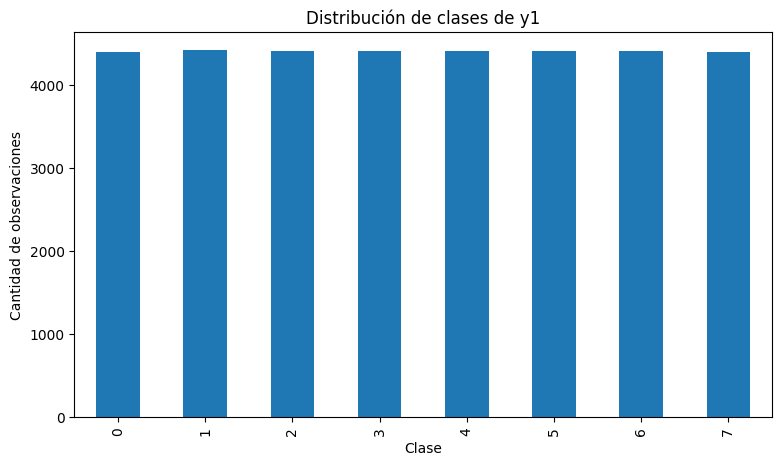

In [22]:
plt.figure(figsize=(9, 5))

df_clf["y1"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribución de clases de y1")
plt.xlabel("Clase")
plt.ylabel("Cantidad de observaciones")

plt.show()

In [23]:
X_clf = df_clf.drop(columns=["y1"])
y_clf = df_clf["y1"]

print("X:", X_clf.shape)
print("y:", y_clf.shape)

print("\nClases:")
print(sorted(y_clf.unique()))

X: (35230, 11)
y: (35230,)

Clases:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [24]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Entrenamiento:", X_clf_train.shape)
print("Prueba:", X_clf_test.shape)

Entrenamiento: (28184, 11)
Prueba: (7046, 11)


In [25]:
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# DECISION TREE CLASSIFIER
# ============================================================

modelo_clf = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

modelo_clf.fit(
    X_clf_train,
    y_clf_train
)

y_clf_pred = modelo_clf.predict(
    X_clf_test
)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_clf = accuracy_score(
    y_clf_test,
    y_clf_pred
)

precision_clf = precision_score(
    y_clf_test,
    y_clf_pred,
    average="macro",
    zero_division=0
)

recall_clf = recall_score(
    y_clf_test,
    y_clf_pred,
    average="macro",
    zero_division=0
)

f1_clf = f1_score(
    y_clf_test,
    y_clf_pred,
    average="macro",
    zero_division=0
)

print("RESULTADOS - DECISION TREE")
print("--------------------------------")
print(f"Accuracy  : {accuracy_clf:.4f}")
print(f"Precision : {precision_clf:.4f}")
print(f"Recall    : {recall_clf:.4f}")
print(f"F1-score  : {f1_clf:.4f}")

RESULTADOS - DECISION TREE
--------------------------------
Accuracy  : 0.7007
Precision : 0.7004
Recall    : 0.7007
F1-score  : 0.7003


In [27]:
print(
    classification_report(
        y_clf_test,
        y_clf_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.75      0.76      0.75       879
           1       0.64      0.58      0.61       883
           2       0.78      0.76      0.77       882
           3       0.73      0.74      0.73       882
           4       0.72      0.73      0.73       880
           5       0.68      0.68      0.68       880
           6       0.67      0.71      0.69       881
           7       0.63      0.65      0.64       879

    accuracy                           0.70      7046
   macro avg       0.70      0.70      0.70      7046
weighted avg       0.70      0.70      0.70      7046



<Figure size 800x800 with 0 Axes>

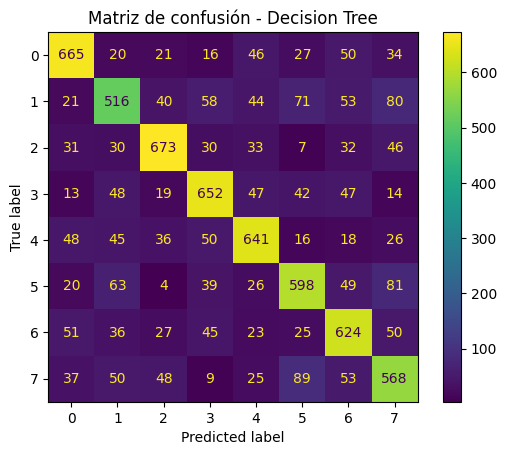

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 8))

ConfusionMatrixDisplay.from_predictions(
    y_clf_test,
    y_clf_pred
)

plt.title("Matriz de confusión - Decision Tree")
plt.show()

In [29]:
# ============================================================
# VALIDACIÓN TRAIN VS TEST - REGRESIÓN
# ============================================================

y_reg_train_pred = modelo_reg.predict(X_reg_train_scaled)

r2_train = r2_score(y_reg_train, y_reg_train_pred)
r2_test = r2_score(y_reg_test, y_reg_pred)

smape_train = smape(y_reg_train, y_reg_train_pred)
smape_test = smape(y_reg_test, y_reg_pred)

print("RIDGE REGRESSION")
print("-----------------------------")
print(f"R2 Train    : {r2_train:.6f}")
print(f"R2 Test     : {r2_test:.6f}")
print(f"SMAPE Train : {smape_train:.4f}%")
print(f"SMAPE Test  : {smape_test:.4f}%")

RIDGE REGRESSION
-----------------------------
R2 Train    : 0.999989
R2 Test     : 0.999990
SMAPE Train : 1.4958%
SMAPE Test  : 1.5604%


In [30]:
# ============================================================
# VALIDACIÓN TRAIN VS TEST - CLASIFICACIÓN
# ============================================================

y_clf_train_pred = modelo_clf.predict(X_clf_train)

accuracy_train = accuracy_score(
    y_clf_train,
    y_clf_train_pred
)

accuracy_test = accuracy_score(
    y_clf_test,
    y_clf_pred
)

f1_train = f1_score(
    y_clf_train,
    y_clf_train_pred,
    average="macro",
    zero_division=0
)

f1_test = f1_score(
    y_clf_test,
    y_clf_pred,
    average="macro",
    zero_division=0
)

print("DECISION TREE")
print("-----------------------------")
print(f"Accuracy Train : {accuracy_train:.4f}")
print(f"Accuracy Test  : {accuracy_test:.4f}")
print(f"F1 Train       : {f1_train:.4f}")
print(f"F1 Test        : {f1_test:.4f}")

DECISION TREE
-----------------------------
Accuracy Train : 1.0000
Accuracy Test  : 0.7007
F1 Train       : 1.0000
F1 Test        : 0.7003


### Análisis del modelo de regresión

El modelo Ridge Regression presentó un desempeño elevado tanto en entrenamiento
como en prueba. Se obtuvo un R² de 0.999989 en entrenamiento y 0.999990 en
prueba, lo que indica que el modelo explica prácticamente toda la variabilidad
de la variable objetivo.

El SMAPE fue de 1.4958% en entrenamiento y 1.5604% en prueba. La poca diferencia
entre ambos conjuntos indica que el modelo mantiene un comportamiento estable
sobre datos no utilizados durante el entrenamiento.

Por lo tanto, el modelo presenta un buen nivel de generalización y cumple con
los valores requeridos de R² mayor a 0.95 y SMAPE menor a 5%.

### Análisis del modelo de clasificación

El Decision Tree Classifier obtuvo un accuracy de 1.0000 y un F1-score de
1.0000 sobre el conjunto de entrenamiento. Sin embargo, en el conjunto de
prueba el accuracy disminuyó a 0.7007 y el F1-score macro a 0.7003.

La diferencia considerable entre los resultados de entrenamiento y prueba
evidencia sobreajuste. El árbol logró ajustarse completamente a los datos de
entrenamiento, pero perdió capacidad de generalización frente a observaciones
nuevas.

Por ello, aunque el modelo logra aproximadamente un 70% de desempeño sobre
el conjunto de prueba, resulta necesario controlar la complejidad del árbol
o evaluar otros algoritmos para mejorar su capacidad de generalización.